# 데이터 형태 파악하기

In [1]:
# ==== 1. 라이브러리 임포트 ====
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ==== 2. 데이터 불러오기 ====
data_dir = "code/data/maze_data_train_9"  # 테스트 데이터셋 경로
inputs = np.load(f"{data_dir}/inputs.npy")       # 미로 입력
solutions = np.load(f"{data_dir}/solutions.npy") # 정답 경로

print("inputs shape:", inputs.shape)
print("solutions shape:", solutions.shape)

inputs shape: (50000, 3, 24, 24)
solutions shape: (50000, 24, 24)


In [3]:
# ==== 3. 샘플 하나 확인 ====
idx = 0  # 첫 번째 미로
maze = inputs[idx]       # (9x9) 형태
solution = solutions[idx]

print("Maze shape:", maze.shape)
print("Solution shape:", solution.shape)

Maze shape: (3, 24, 24)
Solution shape: (24, 24)


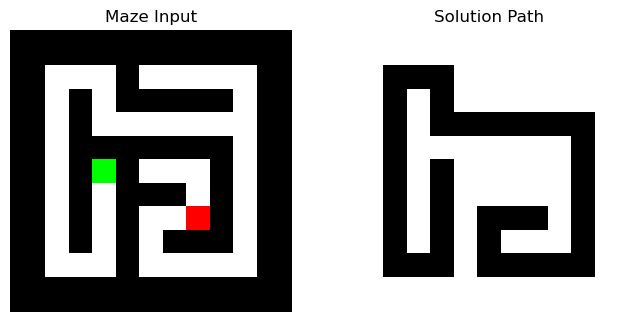

In [4]:
# ==== 4. 시각화 ====

# 만약 maze shape이 (C, H, W)라면 -> (H, W, C)로 변환
if maze.ndim == 3 and maze.shape[0] <= 4:  # 채널이 앞에 있는 경우
    maze = np.transpose(maze, (1, 2, 0))

if solution.ndim == 3 and solution.shape[0] <= 4:
    solution = np.transpose(solution, (1, 2, 0))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# 미로 (0=벽, 1=길)
axes[0].imshow(maze, cmap="gray_r")
axes[0].set_title("Maze Input")

# 솔루션 (0=빈칸, 1=경로)
axes[1].imshow(solution, cmap="gray_r")
axes[1].set_title("Solution Path")

for ax in axes:
    ax.axis("off")

plt.show()

# 9x9 인데 왜 (3, 24, 24)?
* 미로 경로에 해당하는 부분을 세어보면 가로 9, 세로 9가 맞긴 하다.
* 아마도 시각화할 때 각 셀을 여러 픽셀로 확대하여 이미지화해서 24x24로 모델 입력으로 쓰도록 설계된 게 아닐까.
* 24 중 양 옆 2 픽셀(총 4 픽셀)은 padding, 남은 18 픽셀은 9x9를 2배 확대.

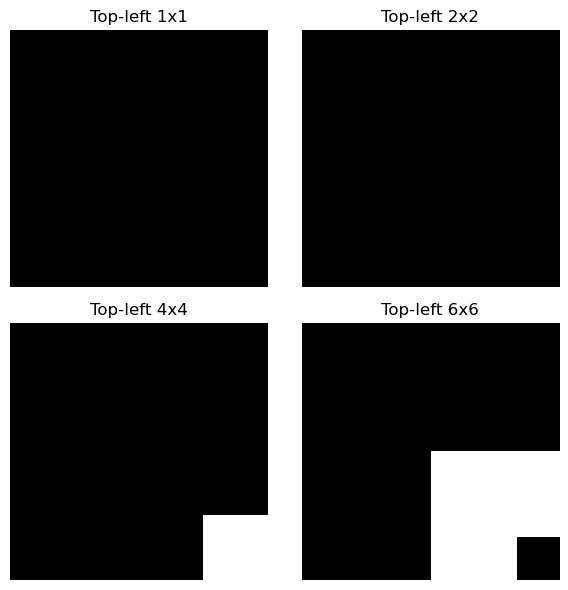

In [25]:
# 잘라낼 크기들
sizes = [1, 2, 4, 6]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for ax, size in zip(axes.flatten(), sizes):
    crop = maze[:size, :size, :]   # 왼쪽 위에서 size×size 영역 추출
    ax.imshow(crop)
    ax.set_title(f"Top-left {size}x{size}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 그럼 13x13와 15x15은?

In [47]:
maze_13 = np.load("code/data/maze_data_train_13/inputs.npy")
maze_13 = maze_13[0]

print("Maze shape:", maze_13.shape)

Maze shape: (3, 32, 32)


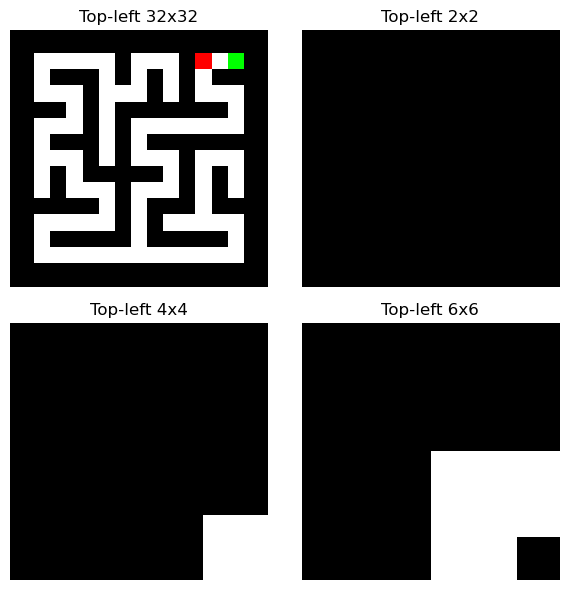

In [49]:
maze_13 = np.transpose(maze_13, (1, 2, 0))

sizes = [32, 2, 4, 6]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for ax, size in zip(axes.flatten(), sizes):
    crop = maze_13[:size, :size, :]   # 왼쪽 위에서 size×size 영역 추출
    ax.imshow(crop)
    ax.set_title(f"Top-left {size}x{size}")
    ax.axis("off")

plt.tight_layout()
plt.show()

* 아마도 3 픽셀만큼 padding을 적용하고, 미로 크기를 2배 확대하여 데이터셋으로 만든 것 같다.

In [44]:
maze_15 = np.load("code/data/maze_data_train_15/inputs.npy")
maze_15 = maze_15[0]

print("Maze shape:", maze_15.shape)

Maze shape: (3, 36, 36)


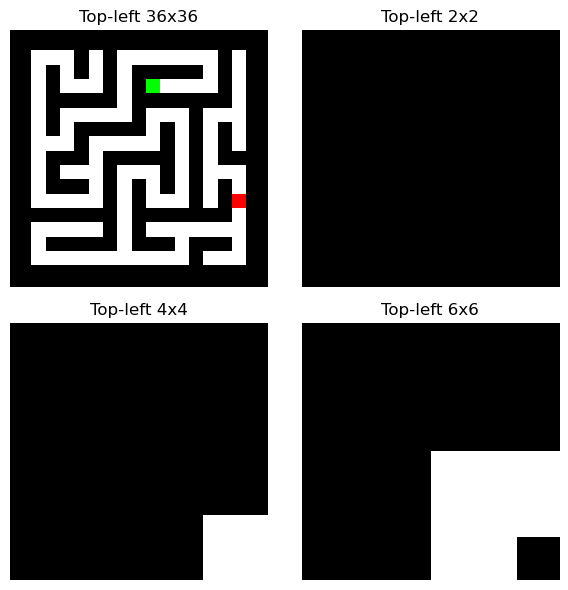

In [46]:
maze_15 = np.transpose(maze_15, (1, 2, 0))

sizes = [36, 2, 4, 6]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for ax, size in zip(axes.flatten(), sizes):
    crop = maze_15[:size, :size, :]   # 왼쪽 위에서 size×size 영역 추출
    ax.imshow(crop)
    ax.set_title(f"Top-left {size}x{size}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 결론
* 미로를 2배 확대한 후(ex. 9x9 -> 18x18) 3 픽셀만큼의 padding을 적용하였다. 
    * 9x9:(9 * 2 + 3 * 2) = 24, (3, 24, 24)
    * 13x13:(13 * 2 + 3 * 2) = 32, (3, 32, 32)
    * 15x15: (15 * 2 + 3 * 2) = 36, (3, 36, 36)

# 9x9, 13x13, 15x15 를 모두 시각화

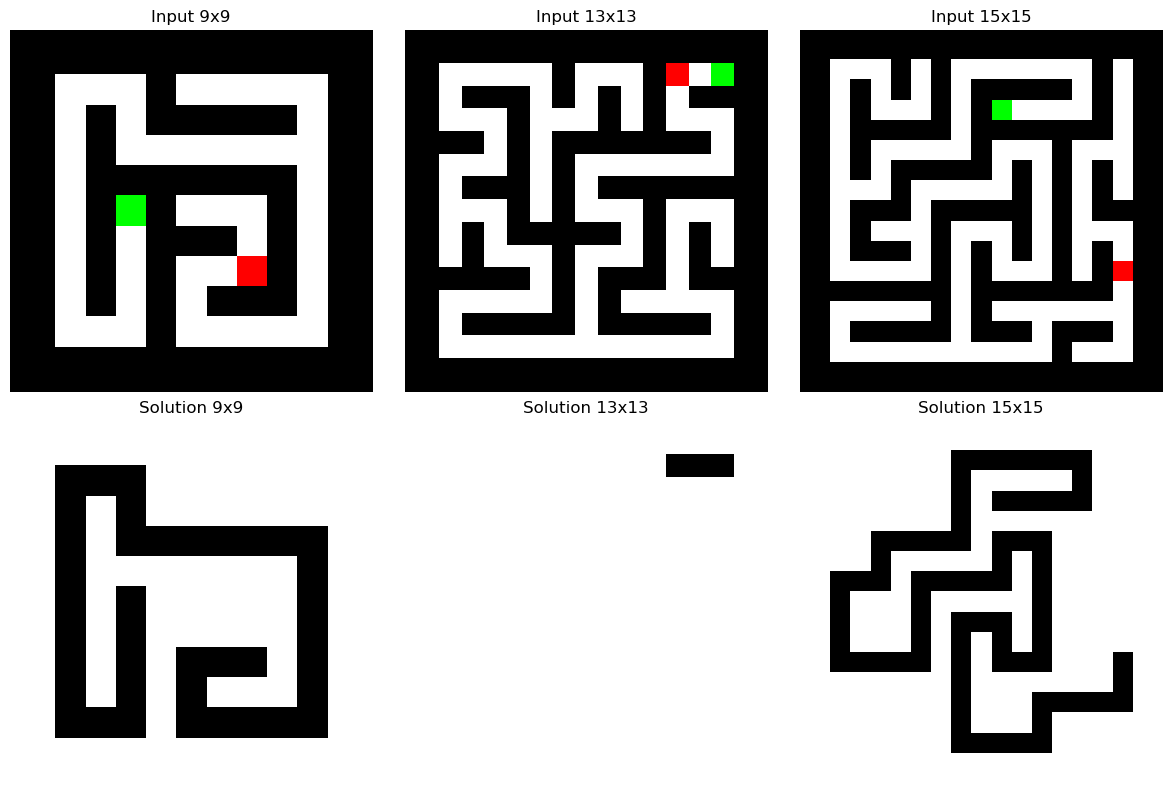

In [24]:
# 사용할 데이터셋 크기
sizes = [9, 13, 15]

fig, axes = plt.subplots(2, len(sizes), figsize=(12, 8))

for col, size in enumerate(sizes):
    # 각 디렉토리에서 불러오기
    data_dir = f"code/data/maze_data_train_{size}"
    inputs = np.load(f"{data_dir}/inputs.npy")       # (N, 3, H, W)
    solutions = np.load(f"{data_dir}/solutions.npy") # (N, H, W) or (N, 3, H, W)

    # 첫 번째 샘플만 보기 (idx=0)
    maze = np.transpose(inputs[0], (1, 2, 0))  # (H, W, 3)

    sol = solutions[0]
    if sol.ndim == 3 and sol.shape[0] == 3:     # (3,H,W) → (H,W,3)
        sol = np.transpose(sol, (1, 2, 0))

    # 첫 번째 줄: 입력 미로
    axes[0, col].imshow(maze)
    axes[0, col].set_title(f"Input {size}x{size}")
    axes[0, col].axis("off")

    # 두 번째 줄: 솔루션
    if sol.ndim == 2:
        axes[1, col].imshow(sol, cmap="gray_r")
    else:
        axes[1, col].imshow(sol)
    axes[1, col].set_title(f"Solution {size}x{size}")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()